In [2]:
from torch.utils.data import DataLoader
from gripper_data import GripperDataset, plot_images, compute_mean_images, load_images
import os
import sys

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

### Dataset and Dataloader
Create dataset and load data

In [3]:
experiment = os.getenv("DATASET_EXPERIMENT") # experiment name
sessions = [1,2] # sessions to load
path = os.getenv("DATASET_PATH") # experiment path

# dataset = GripperDataset(experiment=experiment, sessions=sessions)
dataset = GripperDataset(abs_path=path, sessions=sessions)

dataloader = DataLoader(dataset, batch_size=10, shuffle=True)

Loading data session 1
Loading data session 2


Inspect dataset and dataloader.

- Images -> RGB and with shape (Channels, Height, Width)

- States -> 5 values : x_norm, y_norm, z_norm, rotation, gripper_opening_norm

Number of samples in the dataset:  4767
Number of batches in the dataloader:  477
Shape bottom image:  [3, 640, 480]
Shape top image:  [3, 720, 1280]
Shape state array:  [5]


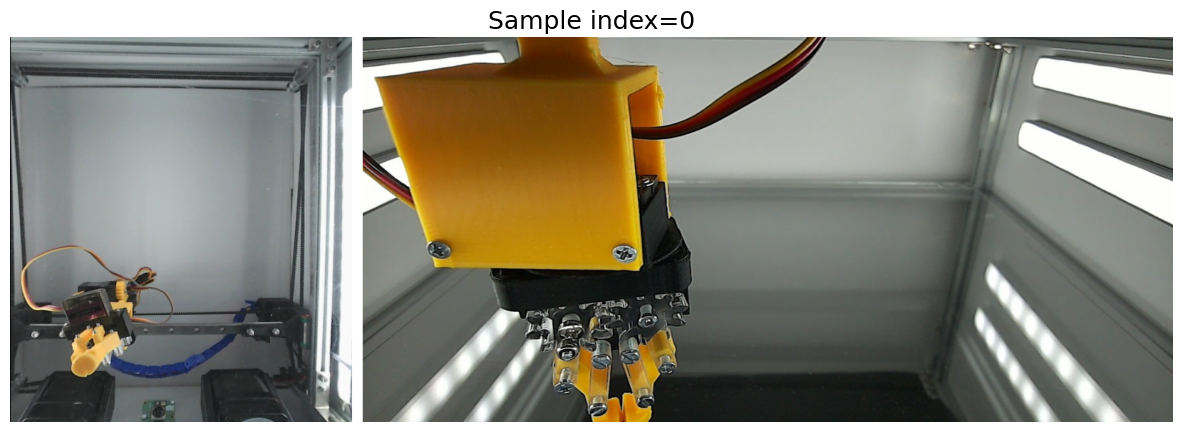

In [4]:
print("Number of samples in the dataset: ", dataset.__len__())
print("Number of batches in the dataloader: ", len(dataloader))
index = 0
bottom_img, top_img, state = dataset[index]

print("Shape bottom image: ", [*bottom_img.shape])
print("Shape top image: ", [*top_img.shape])
print("Shape state array: ", [*state.shape])

plot_images(bottom_img, top_img, title=f"Sample index={index}")

### Mean image
The average of a lot of images is an image of the clean environment, since that is the only static thing while the robot moves. However such average might be biased.

Loading existing mean images
Shape mean bottom image:  [3, 640, 480]
Shape mean top image:  [3, 720, 1280]


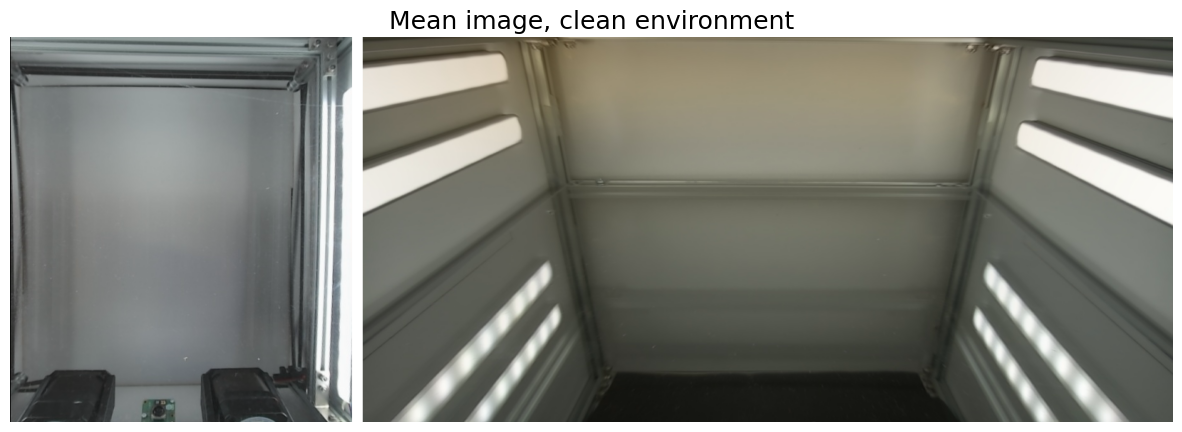

In [6]:
name = "_mean"
path = "clean_environment_images"
mean_bottom_file = os.path.join(path, f"bottom{name}.jpeg")
mean_top_file = os.path.join(path, f"top{name}.jpeg")

# import mean image, clean environment, if it exists
if os.path.exists(mean_bottom_file) and os.path.exists(mean_top_file):
    print("Loading existing mean images")
    mean_bottom, mean_top = load_images(path, name)

else:
    print("Calculating mean images")
    mean_bottom, mean_top = compute_mean_images(dataloader, path=path, name=name)

print("Shape mean bottom image: ", [*mean_bottom.shape])
print("Shape mean top image: ", [*mean_top.shape])
plot_images(mean_bottom, mean_top, title="Mean image, clean environment")

Load dataset with "custom" images type between the follwing folders' name:

- Bottom_image

- Images

- Top_masked_images

- Top_masks

Loading data session 1
Loading data session 2


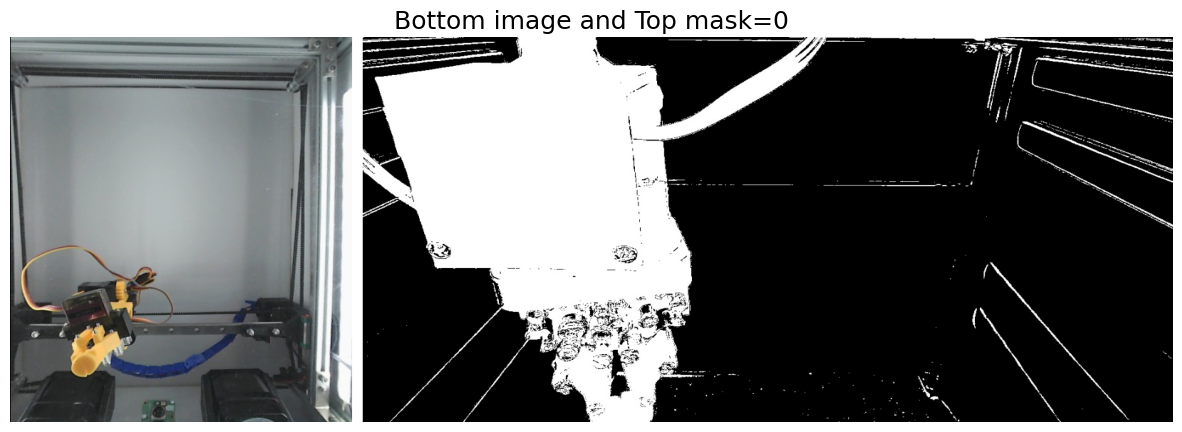

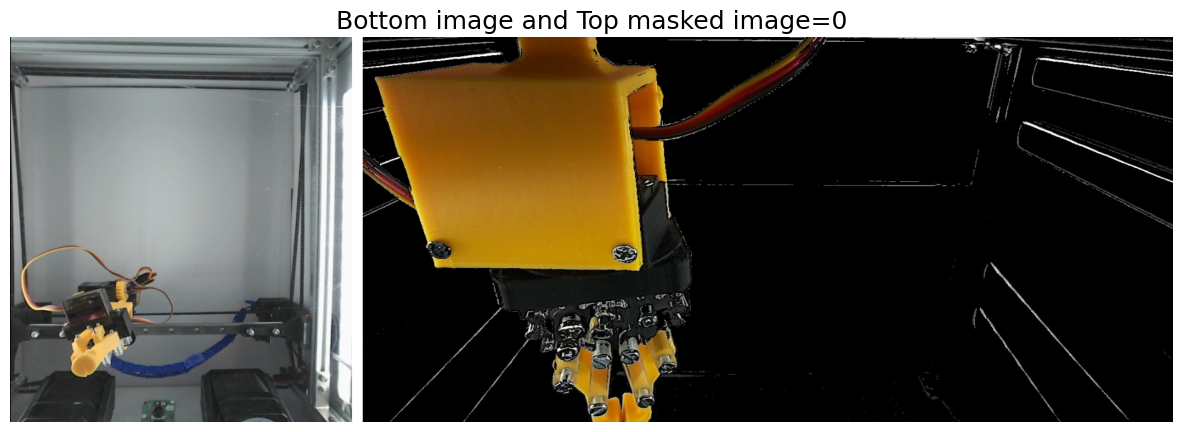

In [13]:
images_to_load = ["Bottom_images", "Top_masks", "Top_masked_images"]
# images_to_load = ["Bottom_images", "Images", "Top_masked_images"]

# dataset = GripperDataset(experiment=experiment, sessions=sessions)
dataset = GripperDataset(abs_path=path, sessions=sessions, images_to_load=images_to_load)
dataloader = DataLoader(dataset, batch_size=10, shuffle=True)

bottom_img, top_mask, top_masked_img, state = dataset[index]
plot_images(bottom_img, top_mask, title=f"Bottom image and Top mask={index}")
plot_images(bottom_img, top_masked_img, title=f"Bottom image and Top masked image={index}")

Transformation for ResNet

- ToTensor()

-  Resize((224,224)) $\to$ break the aspect ratio

   Resize(256) $\to$ resize the shortest side and maintain the aspect ratio for the other

- Normalize() $\to$ normalization using mean and std of ImageNet dataset used for pretraining

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.045356512069702..2.6382462978363037].


Loading data session 1
Loading data session 2


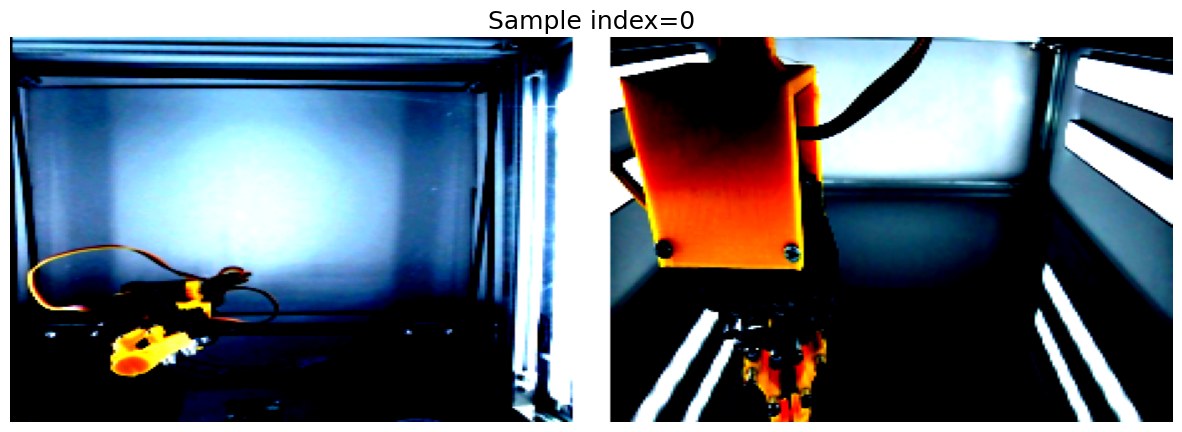

Shape bottom image:  [3, 224, 224]
Shape top image:  [3, 224, 224]
State (rotation normalized):  [0.2705     0.09764285 0.07222223 0.05       0.        ]


In [8]:
from torchvision import transforms 

preprocess = transforms.Compose([
        transforms.ToTensor(),
        transforms.Resize((224,224)),
        # transforms.Resize(256), # resizes the shorter side of the image to 256 pixels while maintaining the aspect ratio
        # transforms.CenterCrop(224), # crops a 224×224 region from the center of the image 
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]), # mean and std of ImageNet dataset used for pretraining
    ])
dataset = GripperDataset(abs_path=path, sessions=sessions, transform=preprocess)

bottom_img, top_img, state = dataset[index]
plot_images(bottom_img, top_img, title=f"Sample index={index}")
print("Shape bottom image: ", [*bottom_img.shape])
print("Shape top image: ", [*top_img.shape])
print("State (rotation normalized): ", state.numpy())